In [2]:
import numpy as np
import random
import itertools
import pandas as pd
import os
import ot
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import glob 
from copy import copy
from scipy.sparse import csr_matrix
from scipy.stats import pareto
import scipy.spatial.distance as ssd
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.decomposition import NMF
from sklearn.metrics.cluster import normalized_mutual_info_score as NMI
from EDRep_main.EDRep import NodeEmbedding  
from tqdm.notebook import tqdm



In [3]:
def generateSequence(outputfolder, model, args, n_graphs, verbose = True, append_name = '.csv'):
    '''This function generates a sequence of graphs that have a common generative model in each block
    
    Use: generateSequence(outputfolder, model, args, n_graphs)
    
    Inputs: 
        * outputfolder : directory to which the files will be saved
        * model (function): function of the generative model to be considered
        * args (list of lists): arguments of model
        * n_graphs (int): number of graphs to be generated

    Optional inputs:
        * verbose (boolean): if True (default) prints the progress bar
        * append_name (string): what goes at the end of the file name. Can be used to change the extension or also part of the name of the file. By default `.csv`
        
    Outputs:
        * this function will output the edgelist representation of the generated graphs numbered in ascending order.       
    '''
    
    for i in range(n_graphs):
        df = model(args)
        idx_str = str(start_idx + i).zfill(2)
        
        df.to_csv(outputfolder + '/EL' + idx_str + append_name, index = False)

        if verbose:
            print("[%--25s] %d%%" % ('='*(int(i/(n_graphs)*25)) + '>', (i+1)/(n_graphs)*100), end='\r')
    return

def generateSequence(outputfolder, model, args, n_graphs, start_idx=1, verbose=True, append_name='.csv'):
    for i in range(n_graphs):
        df = model(args)
        
        # Creiamo un indice progressivo con lo zero davanti (es. 01, 02... 10... 50)
        idx_str = str(start_idx + i).zfill(2)
        
        # Salviamo il file usando il nuovo indice
        df.to_csv(outputfolder + '/EL' + idx_str + append_name, index = False)

        if verbose:
            print("[%--25s] %d%%" % ('='*(int(i/(n_graphs)*25)) + '>', (i+1)/(n_graphs)*100), end='\r')
    return

def DCSBM(args):
    ''' 
    Function that generates a graph from the degree-corrected stochastic block model with
    n nodes and k communities
    
    Note that, with an appropriate choice of the parameters, this function can be used to
    generate an SBM or and ER random graph
    
    Use:
        edge_list = DCSBM(C,c, ℓ, θ, symmetric, make_connected)
    Inputs:
        args = C, c, ℓ, θ
            * C (array of size k x k) : affinity matrix of the network C
            * c (scalar) : average degree of the network
            * ℓ (array of size n) : vector containing the label of each node
            * θ  (array of size n) : vector with the intrinsic probability connection of each node
            * symmetric (bool): if True it returns an undirected graph
            * make_connected (bool): if True forces the graph to be connected adding edges
    
    Outputs:
        * edge_list (pandas dataframe) : edge list representation of the graph (ij)
        
    '''
    
    C, c, ℓ, θ, symmetric, make_connected  = args

    # number of communities
    k = len(np.unique(ℓ))
    
    # number of nodes
    n = len(θ)
    
    # (k x n) matrix where we store the value of the affinity wrt a given label for each node
    c_v = C[ℓ].T
    
    fs = list()
    ss = list()

    # we choose the nodes that should get connected wp = θ_i/n
    if symmetric:
        first = np.random.choice(n,int(n*c/2),p = θ/n)

    else:  
        first = np.random.choice(n,int(n*c),p = θ/n) 

    for i in range(k): 
        v = θ*c_v[i]
        
        # among the nodes of first, select those with label i
        first_selected = first[ℓ[first] == i]
        fs.append(first_selected.tolist())
        
        # choose the nodes to connect to the first_selected
        second_selected = np.random.choice(n,len(first_selected), p = v/np.sum(v))
        ss.append(second_selected.tolist())

    fs = list(itertools.chain(*fs))
    ss = list(itertools.chain(*ss))

    fs = np.array(fs)
    ss  = np.array(ss)


    # add nodes not appearing in the vector first, to ensure the graph is connected
    if make_connected:
        idx = np.arange(n)[np.logical_not(np.isin(np.arange(n), fs))]
        fs = np.concatenate([fs, idx])
        ss = np.concatenate([ss, np.argmax(θ)*np.ones(len(idx))])
    

    # create the edge list from the connection defined earlier
    edge_list = np.column_stack((fs,ss)) 
    
    # remove edges appearing more then once
    edge_list = np.unique(edge_list, axis = 0) 

    # replace self edges
    idx = edge_list[:,0] == edge_list[:,1]
    edge_list[:,1][idx] += 1
    idx = edge_list[:,1] == n
    edge_list[:,1][idx] = 0

    if symmetric:
        df = pd.DataFrame(columns = ['i', 'j'])
        M = np.maximum(edge_list[:,0], edge_list[:,1])
        m = np.minimum(edge_list[:,0], edge_list[:,1])
        df.i = np.concatenate([M, m])
        df.j = np.concatenate([m, M])

    else:
        df = pd.DataFrame(columns = ['i', 'j'])
        df.i = edge_list[:,0]
        df.j = edge_list[:,1]

    # add an edge to nodes with degree 0
    A = csr_matrix((np.ones(len(df)), (df.i, df.j)), shape = (n,n))
    d = A@np.ones(n)
    idx = d == 0


    return df

def EmbDistance(X, Y, distance_type = 'unmatched'):
    '''This function computes the distance between 

    Use: d = EmbDistance(X, Y)

    Inputs:
        * X, Y (arrays): input embeddings corresponding to the two temporal graphs. The number of rows of the two matrices must be the same.
        
    Optional inputs:
        * distance_type (string): can be 'unmatched' or 'matched'

    Output:
        * d (float): distance between the two graphs.
    '''

    n1, d1 = X.shape
    n2, d2 = Y.shape

    # run initial checks

    if d1 != d2:
        raise DeprecationWarning('The embedding matrices have different dimensions')
    else:
        d = d1

    
    if distance_type not in ['unmatched', 'matched']:
        raise DeprecationWarning('The distance type is not valid')
    
    else:
        if (distance_type == 'matched') and (n1 != n2):
            raise DeprecationWarning("The input matrices do not have the same size")
        else:
            n = n1

    if distance_type == 'matched':
        Mxx = X.T@X
        Mxy = X.T@Y
        Myy = Y.T@Y
        d = np.sqrt(np.abs(np.linalg.norm(Mxx)**2 + np.linalg.norm(Myy)**2 - 2*np.linalg.norm(Mxy)**2))

    else:
        n1, n2 = X.shape[0], Y.shape[0]
        λ1 = np.linalg.eigvalsh(X.T@X)/n1
        λ2 = np.linalg.eigvalsh(Y.T@Y)/n2
        d = np.linalg.norm(λ1-λ2)
  
    return d
def get_adj(filepath):
    df = pd.read_csv(filepath)
    G = nx.from_pandas_edgelist(df, 'i', 'j')
    A = nx.adjacency_matrix(G).astype(float)

    return A
def node_embedding(g, dim_embedding,seed=42):
    rdn_state = np.random.get_state()
    random.seed(seed)
    np.random.seed(seed)
    embedding_a = NodeEmbedding(g, dim=dim_embedding, k=1, verbose=False)
    X_total = embedding_a.X
    np.random.set_state(rdn_state)
    return X_total

def w2_distance(emb_1, emb_2):
    S_1=emb_1@emb_1.T
    S_2=emb_2@emb_2.T
    vals_S_1=S_1.flatten()
    vals_S_2=S_2.flatten()
    wd2 = ot.wasserstein_1d(vals_S_1, vals_S_2, p=2)**(1/2)
    return wd2
def create_embeddings(path_files, dim):
    embeddings = []

    for file in tqdm(path_files, desc="Calcolando embeddings"):
        a = get_adj(file)
        emb = node_embedding(a, dim)
        embeddings.append(emb)
        
    return embeddings

def distances(embeddings, n):
    old_d = []
    new_d = []
    subset = embeddings[:n]
    
    k = len(subset)

    total_iters = k * (k - 1) // 2

    for a, b in tqdm(itertools.combinations(subset, 2), total=total_iters, desc="Calcolando distanze"):
        old = EmbDistance(a, b, 'unmatched')
        new = w2_distance(a, b)
        old_d.append(old)
        new_d.append(new)
 
    return old_d, new_d

def comparison_plot(old_d, new_d, name):
    plt.figure(figsize=(8, 6))

    plt.scatter(old_d, new_d,alpha=0.6)

    plt.xlabel("unmatched")
    plt.ylabel("wasserstein")
    plt.title(f"Comparing distances for {name}")
    plt.grid(True)
    plt.show()
def NMF_kmeans(M,k):

    n, _ = M.shape
    Mt = M + np.eye(n)*np.mean(M[M.nonzero()])
    Mt = Mt/np.mean(Mt)
    Y = NMF(n_components = k).fit(Mt).components_
    kmeans = KMeans(n_clusters = k, n_init = 10).fit(Y.T)
    return kmeans.labels_, np.abs(kmeans.score(Y.T))

def ClusterNMF(M, k):
    
    est_ℓ, score = NMF_kmeans(M, k)
    
    for i in range(20):
        est_ℓ_, score_ = NMF_kmeans(M, k)
        if score_ < score:
            score = score_
            est_ℓ = est_ℓ_
            
    return est_ℓ
#PARAMETRI CONDIVISI 
n_nodes = 1000
γ = 0.8 
symmetric = True
make_connected = True
c = 10 

In [4]:
def _sample_pareto(N, alpha, loc=0, scale=1, mean=None):
    """
    Sample N values from a pareto distribution
    """
    b = alpha-1
    r = pareto.rvs(b, loc=loc, scale=scale, size=N)
    if mean:
        r = (r/r.mean()*mean).round()
    return r

def getDegreeFromPareto(n, c, alpha):

    fitness_pareto = np.maximum(_sample_pareto(n, 3.2), 1e-12)
    fitness_pareto = fitness_pareto/np.mean(fitness_pareto)
    fitness_binomial = np.maximum(np.random.binomial(n, c/n, n)/c, 1e-12)
    fitness = np.exp(np.log(fitness_binomial)*(1-alpha) + np.log(fitness_pareto)*alpha)
    theta = fitness/np.mean(fitness)
    degree_sequence = np.maximum(np.random.binomial(n-1, np.minimum(1,theta/n*c)), np.ones(n))
    # degree_sequence = np.random.binomial(n-1, np.minimum(1,theta/n*c))

    return degree_sequence


In [14]:

def gen_with_conf_model(args):
    n, c, alpha = args
    
    degree_sequence = getDegreeFromPareto(n, c, alpha)
    degree_sequence = np.round(degree_sequence).astype(int)

    if sum(degree_sequence) % 2 != 0:
        degree_sequence[-1] += 1

    G = nx.configuration_model(degree_sequence)
    
    G = nx.Graph(G) 
    G.remove_edges_from(nx.selfloop_edges(G))

    df = pd.DataFrame(G.edges(), columns=['i', 'j'])
    return df


output_folder_conf = r"C:\Users\Utente\Desktop\progetto vscode\data\synthetic_graphs\generated_configuration\conf"
alpha_conf = np.linspace(0, 1, 5)

start_idx = 1 

for a in alpha_conf:
    print(f"\n alpha = {a}")

    n_conf = np.random.randint(int(n_nodes*(1-γ)), int(n_nodes*(1+γ)))

    args_conf = (n_conf, c, a)
    
    current_output_folder_conf = f"{output_folder_conf}_alpha_{a}"
    if not os.path.exists(current_output_folder_conf):
        os.makedirs(current_output_folder_conf)
  
    generateSequence(
        outputfolder=current_output_folder_conf, 
        model=gen_with_conf_model, 
        args=args_conf,         
        n_graphs=7,           
        verbose=True             
    )
    
    print(f"\n Grafi salvati in: {current_output_folder_conf}")


 alpha = 0.0
[=====================>   ] 100%
 Grafi salvati in: C:\Users\Utente\Desktop\progetto vscode\data\synthetic_graphs\generated_configuration\conf_alpha_0.0

 alpha = 0.25
[=====================>   ] 100%
 Grafi salvati in: C:\Users\Utente\Desktop\progetto vscode\data\synthetic_graphs\generated_configuration\conf_alpha_0.25

 alpha = 0.5
[=====================>   ] 100%
 Grafi salvati in: C:\Users\Utente\Desktop\progetto vscode\data\synthetic_graphs\generated_configuration\conf_alpha_0.5

 alpha = 0.75
[=====================>   ] 100%
 Grafi salvati in: C:\Users\Utente\Desktop\progetto vscode\data\synthetic_graphs\generated_configuration\conf_alpha_0.75

 alpha = 1.0
[=====================>   ] 100%
 Grafi salvati in: C:\Users\Utente\Desktop\progetto vscode\data\synthetic_graphs\generated_configuration\conf_alpha_1.0


In [15]:
embeddings_alpha_conf = {}

base_conf_path = r"C:\Users\Utente\Desktop\progetto vscode\data\synthetic_graphs\generated_configuration\conf"

for a in np.linspace(0, 1, 5):

    cartella_corrente_conf = f"{base_conf_path}_alpha_{a}"

    path_files_conf = glob.glob(os.path.join(cartella_corrente_conf, "*.csv"))
    path_files_conf = sorted(path_files_conf)
    
    print(f"Embedding per alpha = {a} ({len(path_files_conf)} grafi, da {cartella_corrente_conf})...")

    if len(path_files_conf) == 0:
        print("Nessun file trovato in questa cartella")
        continue
        
    emb_list_conf = create_embeddings(path_files_conf, dim=32)
    embeddings_alpha_conf[a] = emb_list_conf

Embedding per alpha = 0.0 (7 grafi, da C:\Users\Utente\Desktop\progetto vscode\data\synthetic_graphs\generated_configuration\conf_alpha_0.0)...


Calcolando embeddings:   0%|          | 0/7 [00:00<?, ?it/s]

Embedding per alpha = 0.25 (7 grafi, da C:\Users\Utente\Desktop\progetto vscode\data\synthetic_graphs\generated_configuration\conf_alpha_0.25)...


Calcolando embeddings:   0%|          | 0/7 [00:00<?, ?it/s]

Embedding per alpha = 0.5 (7 grafi, da C:\Users\Utente\Desktop\progetto vscode\data\synthetic_graphs\generated_configuration\conf_alpha_0.5)...


Calcolando embeddings:   0%|          | 0/7 [00:00<?, ?it/s]

Embedding per alpha = 0.75 (7 grafi, da C:\Users\Utente\Desktop\progetto vscode\data\synthetic_graphs\generated_configuration\conf_alpha_0.75)...


Calcolando embeddings:   0%|          | 0/7 [00:00<?, ?it/s]

Embedding per alpha = 1.0 (7 grafi, da C:\Users\Utente\Desktop\progetto vscode\data\synthetic_graphs\generated_configuration\conf_alpha_1.0)...


Calcolando embeddings:   0%|          | 0/7 [00:00<?, ?it/s]

Calcolando distanze:   0%|          | 0/595 [00:00<?, ?it/s]

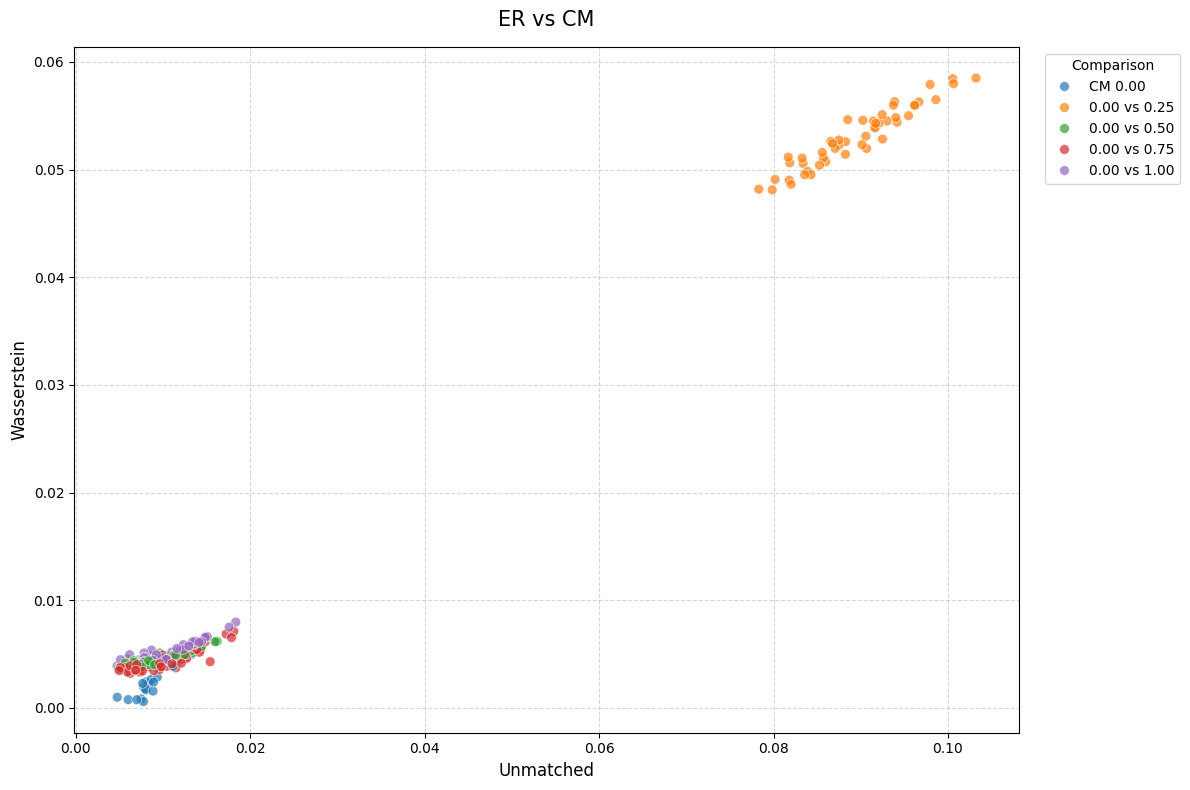

In [16]:

all_embeddings_conf = []
labels_conf = []

for a, emb_list_conf in embeddings_alpha_conf.items():
    for emb in emb_list_conf:
        all_embeddings_conf.append(emb)
        labels_conf.append(a)

N = len(all_embeddings_conf)

tot_combinazioni_conf = N * (N - 1) // 2
unmatched_dists_conf = []
wasserstein_dists_conf = []
categories_conf = []

for i, j in tqdm(itertools.combinations(range(N), 2), total=tot_combinazioni_conf, desc="Calcolando distanze"):
        emb_i = all_embeddings_conf[i]
        emb_j = all_embeddings_conf[j]
        
        a_i = labels_conf[i]
        a_j = labels_conf[j]
        
        unmatched_dists_conf.append(EmbDistance(emb_i, emb_j, 'unmatched'))
        wasserstein_dists_conf.append(w2_distance(emb_i, emb_j))

        if a_i == a_j:
            categories_conf.append(f"CM {a_i:.2f}")
        else:
            a_min, a_max = sorted([a_i, a_j])
            categories_conf.append(f"{a_min:.2f} vs {a_max:.2f}")
    
plt.figure(figsize=(12, 8)) 

df_plot = pd.DataFrame({
    'Unmatched': unmatched_dists_conf,
    'Wasserstein': wasserstein_dists_conf,
    'Type': categories_conf
})
categories_conf_keep= [
    "CM 0.00",
    "0.00 vs 0.25",
    "0.00 vs 0.50",
    "0.00 vs 0.75",
    "0.00 vs 1.00"
]

df_filtered = df_plot[df_plot['Type'].isin(categories_conf_keep)]


sns.scatterplot(
    data=df_filtered, 
    x='Unmatched',
    y='Wasserstein',
    hue='Type',
    hue_order=categories_conf_keep, 
    palette='tab10',            
    alpha=0.7,
    s=50
)

plt.title("ER vs CM", fontsize=15, pad=15)
plt.xlabel("Unmatched", fontsize=12)
plt.ylabel("Wasserstein", fontsize=12)

plt.legend(title="Comparison", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [17]:
n=7
D_old_conf = squareform(unmatched_dists_conf)
D_new_conf = squareform(wasserstein_dists_conf)
n_graphs_per_class_conf = n
n_classes_conf = 5
 
ℓ_conf= np.concatenate([[i for _ in range(n_graphs_per_class_conf)] for i in range(n_classes_conf)])
k_conf = len(np.unique(ℓ_conf)) 

score_old_conf = NMI(ClusterNMF(D_old_conf, k_conf), ℓ_conf)
score_new_conf = NMI(ClusterNMF(D_new_conf, k_conf), ℓ_conf)

print(f"Unmatched OLD (Unmatched): {score_old_conf:.4f}")
print(f"Unmatched NEW (Wasserstein): {score_new_conf:.4f}")

c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: 

Unmatched OLD (Unmatched): 0.6425
Unmatched NEW (Wasserstein): 0.8033


c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\src\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


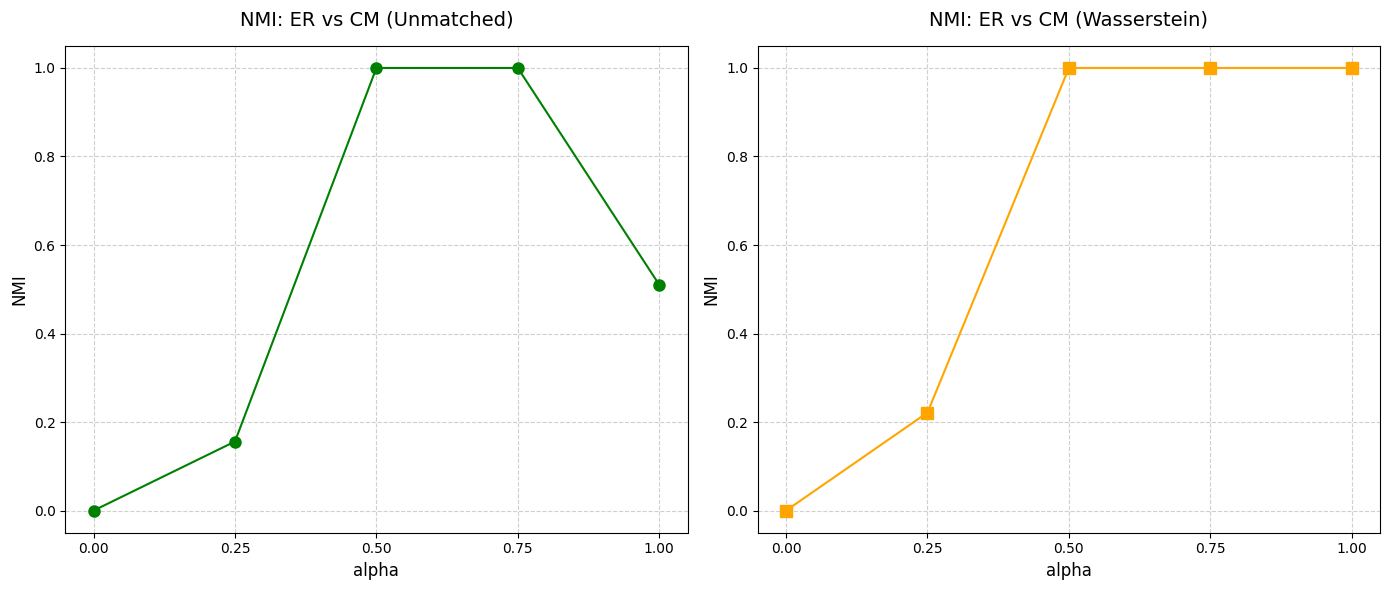

In [ ]:
n=7
alpha_conf = np.linspace(0, 1, 5)

nmi_unmatched_conf = []
nmi_wasserstein_conf = []

# 2. Calcolo iterativo della NMI per ciascun alpha
for i, a in enumerate(alpha_conf):
    if i == 0:
        # Separare alpha=0 da alpha=0 non ha senso ai fini della classificazione.
        # Fissiamo la NMI a 0 come baseline.
        nmi_unmatched_conf.append(0.0)
        nmi_wasserstein_conf.append(0.0)
        continue
        
    # Creiamo gli indici: i primi 20 grafi (alpha=0.0) + i 20 grafi relativi all'alpha corrente
    idx = np.concatenate([np.arange(0, n), np.arange(i*n, (i+1)*n)])
    
    # Estraiamo le sottomatrici 40x40 relative a questo subset
    D_old_sub = D_old_conf[np.ix_(idx, idx)]
    D_new_sub = D_new_conf[np.ix_(idx, idx)]
    
    # Creiamo le vere etichette (Ground Truth): 
    # 0 per la prima classe (alpha=0) e 1 per la seconda classe (alpha > 0)
    l_sub = np.concatenate([np.zeros(n), np.ones(n)])
    
    # Clustering a 2 classi sfruttando la tua funzione NMF
    est_l_old = ClusterNMF(D_old_sub, k=2)
    est_l_new = ClusterNMF(D_new_sub, k=2)
    
    # Calcolo dei punteggi NMI
    nmi_unmatched_conf.append(NMI(est_l_old, l_sub))
    nmi_wasserstein_conf.append(NMI(est_l_new, l_sub))

# 3. Plotting dei due grafici affiancati
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Grafico 1: Distanza Unmatched
ax1.plot(alpha_conf, nmi_unmatched_conf, marker='o', linestyle='-', color='green', markersize=8)
ax1.set_title("NMI: ER vs CM (Unmatched)", fontsize=14, pad=15)
ax1.set_xlabel("alpha", fontsize=12)
ax1.set_ylabel("NMI", fontsize=12)
ax1.set_xticks(alpha_conf)
ax1.set_ylim(-0.05, 1.05)
ax1.grid(True, linestyle='--', alpha=0.6)

# Grafico 2: Distanza Wasserstein
ax2.plot(alpha_conf, nmi_wasserstein_conf, marker='s', linestyle='-', color='orange', markersize=8)
ax2.set_title("NMI: ER vs CM (Wasserstein)", fontsize=14, pad=15)
ax2.set_xlabel("alpha", fontsize=12)
ax2.set_ylabel("NMI", fontsize=12)
ax2.set_xticks(alpha_conf)
ax2.set_ylim(-0.05, 1.05)
ax2.grid(True, linestyle='--', alpha=0.6)

# Aggiusta il layout per evitare sovrapposizioni
plt.tight_layout()
plt.show()